# 04 Scaling Heatmaps


In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from config import PROCESSED_DATAFRAMES_DIR
from notebook_utils.general import parse_active_space, save_figure
from notebook_utils.graphs import (
    plot_h_s_element_regression,
    plot_reordered_overlap_heatmaps,
    plot_shot_overlap_heatmaps,
    show_scrollable_figs,
)
from notebook_utils.operators import get_operator_labels, get_qse_operators

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
SV_DATAFRAME_PATH = PROCESSED_DATAFRAMES_DIR / "sv_qse_data.pkl"
SHOTS_DATAFRAME_PATH = PROCESSED_DATAFRAMES_DIR / "shots_qse_data.pkl"

df_sv = pd.read_pickle(SV_DATAFRAME_PATH)
df_shots = pd.read_pickle(SHOTS_DATAFRAME_PATH)

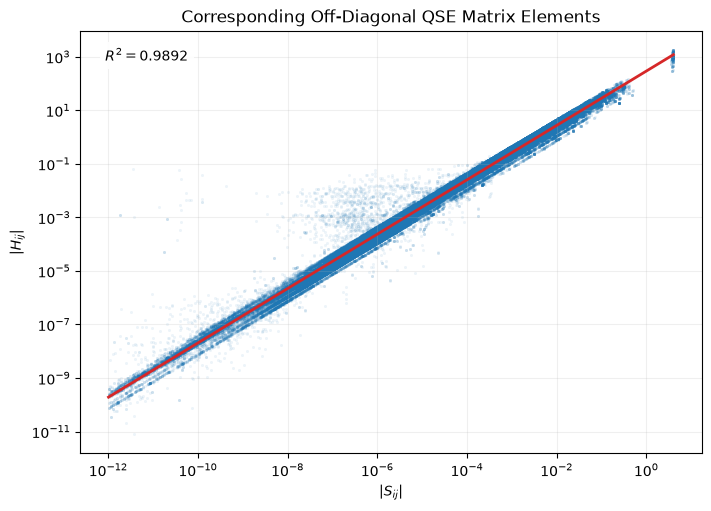

In [5]:
# First look at both the Hij and Sij terms correlation
df_uccsd = df_sv[df_sv["ansatz"] == "UCCSD"]
h_s_points = []

for row in df_uccsd.itertuples(index=False):
    upper_triangle = np.triu_indices_from(row.S, k=1)
    s_elements = np.abs(row.S[upper_triangle])
    h_elements = np.abs(row.H[upper_triangle])
    h_s_points.extend(zip(s_elements, h_elements))

h_s_figure = plot_h_s_element_regression(h_s_points)
save_figure(h_s_figure, "matrix_heatmaps", "uccsd_h_s_element_regression")

plt.show()

## Matrix Heatmaps

In [6]:
"""
The heatmaps are first re ordered instead of from the original generator function
They are first sorted by category (Number occupied -> OV -> The rest)
Within each category, the labels for their spatial orbitals are used to sort them 
For every active space, the permutation order is calculated once in operator_metadata
"""
active_spaces = sorted(df_sv["active_space"].unique(), key=parse_active_space)
expansions = ("singlet", "triplet")
operator_metadata = {
    active_space: {
        expansion: list(zip(*get_operator_labels(operators, active_space)))
        for expansion, operators in zip(expansions, get_qse_operators(active_space))
    }
    for active_space in active_spaces
}

CATEGORY_ORDER = {"Number occupied": 0, "OV": 1, "Rest": 2}


def reorder_mat(matrix, active_space, expansion):
    metadata = operator_metadata[active_space][expansion]
    permutation = sorted(
        range(len(metadata)),
        key=lambda index: (CATEGORY_ORDER[metadata[index][0]], metadata[index][1]),
    )
    return np.asarray(matrix)[np.ix_(permutation, permutation)]


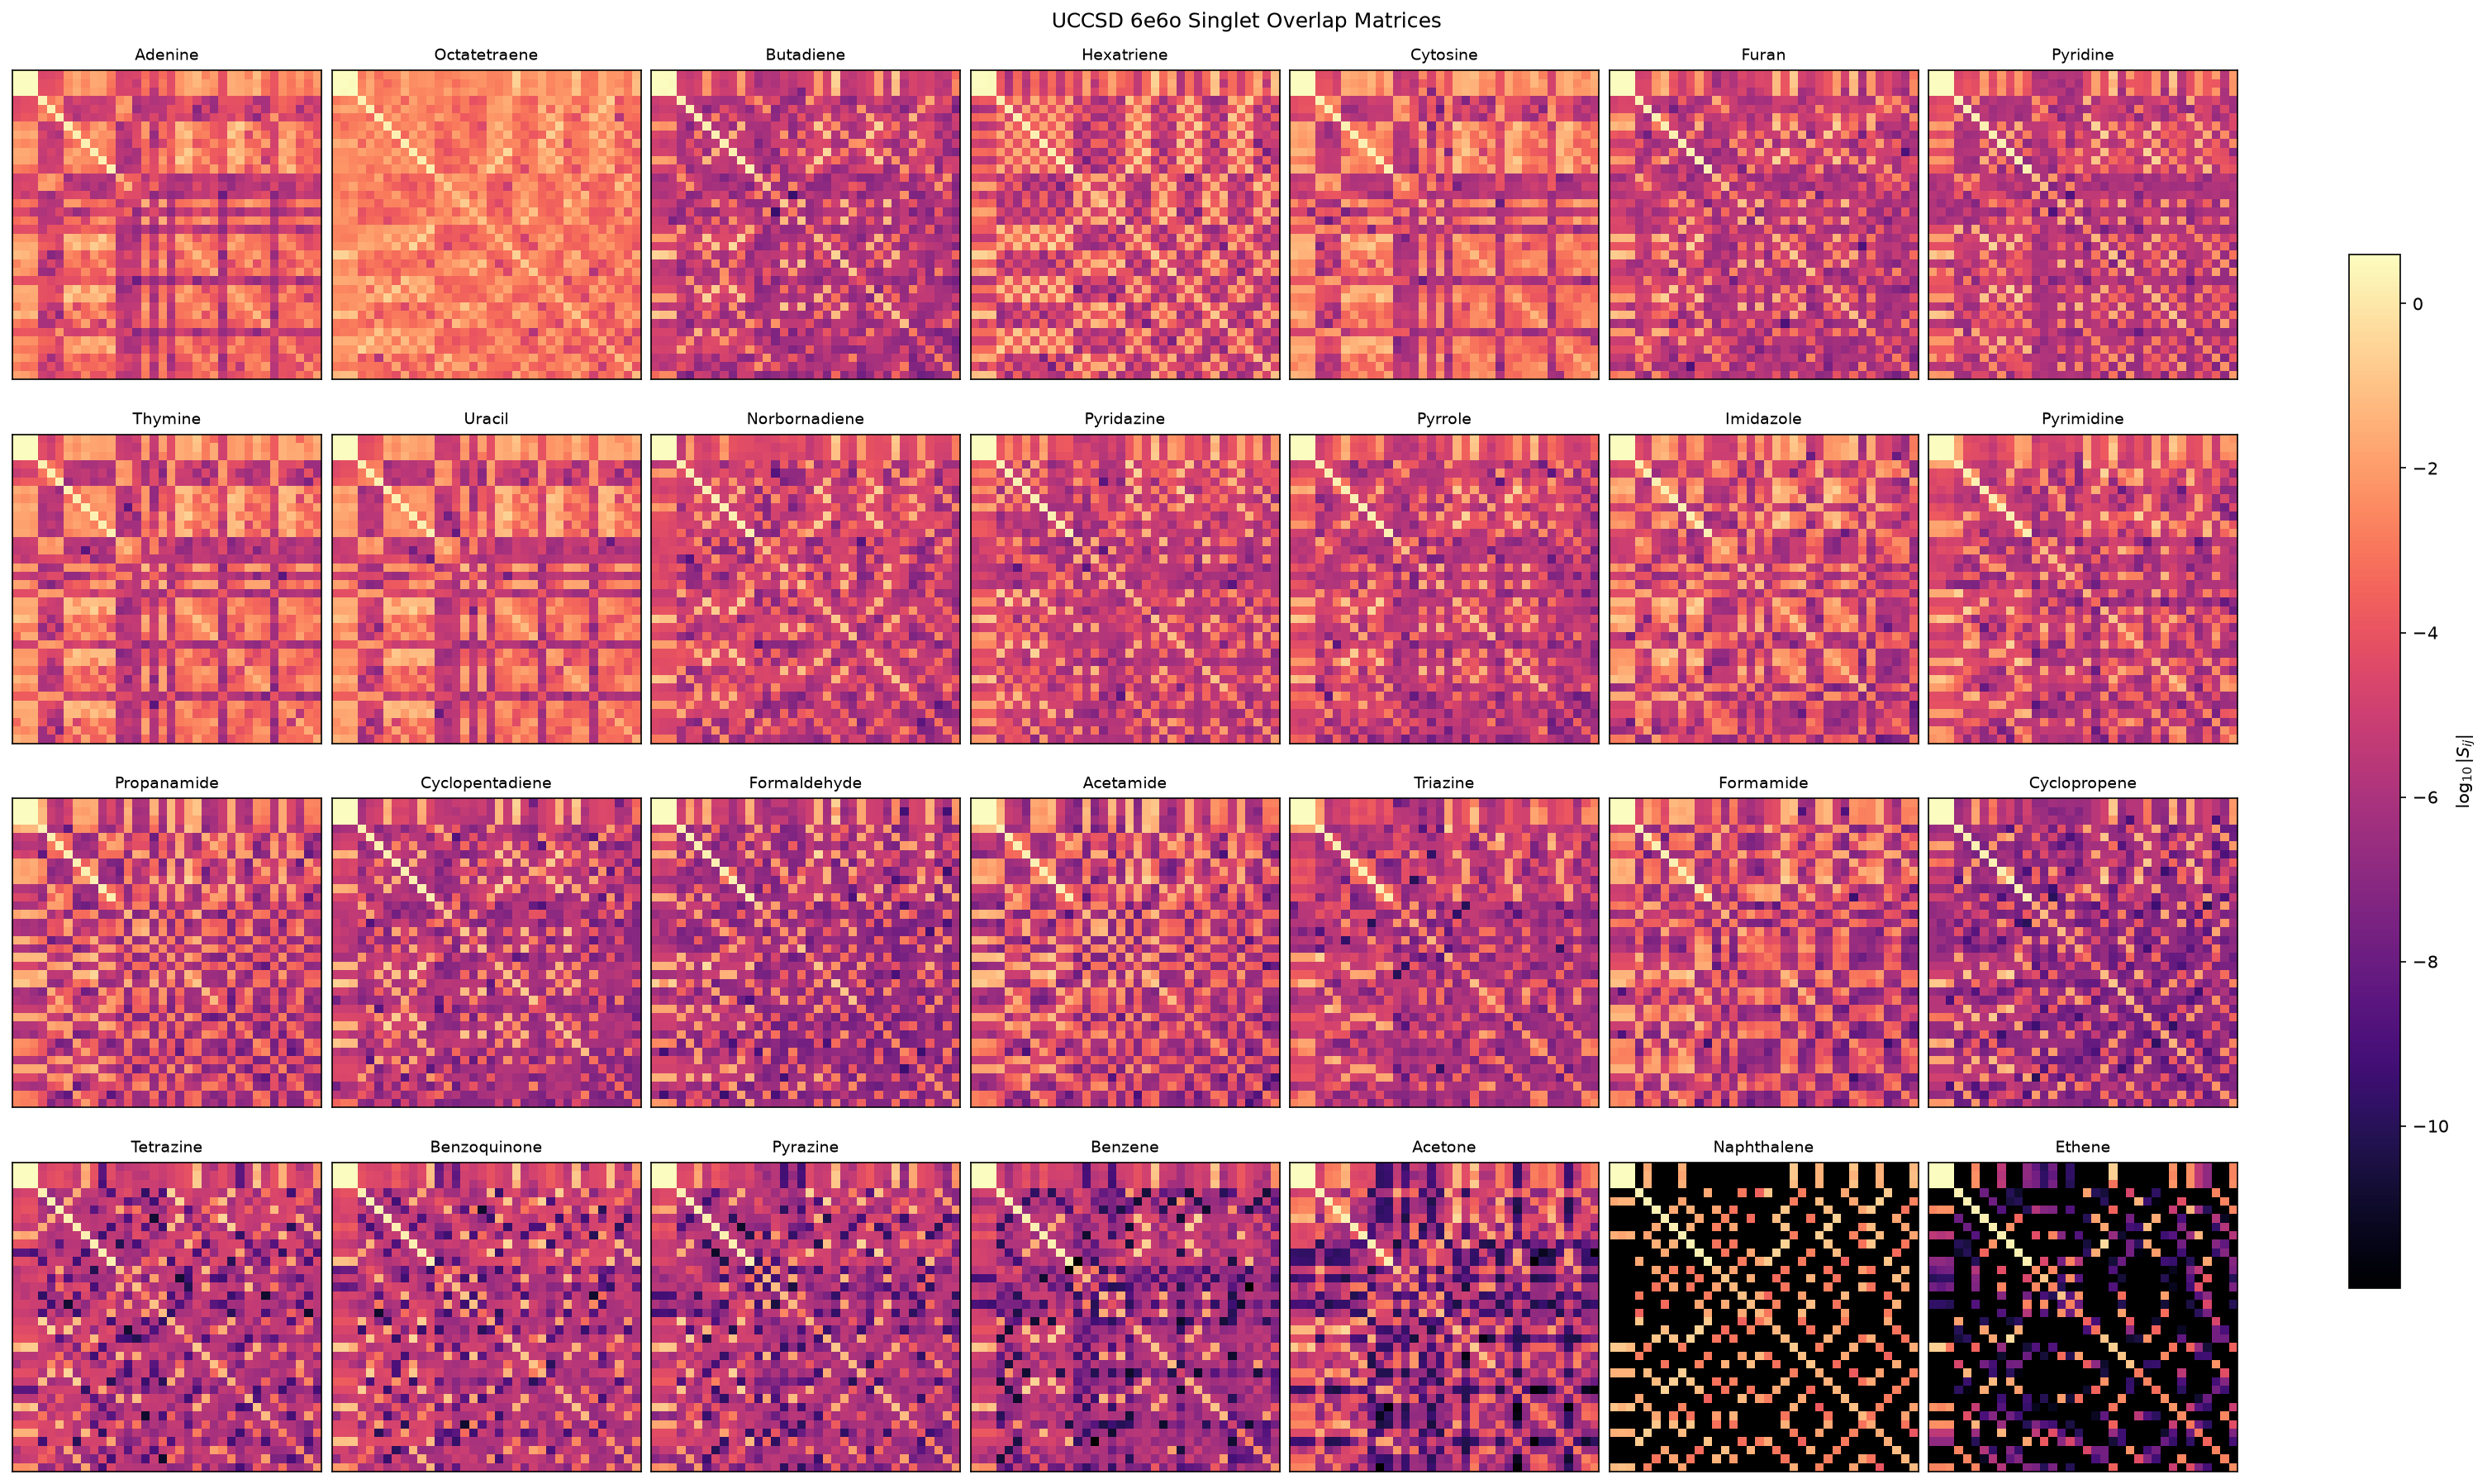
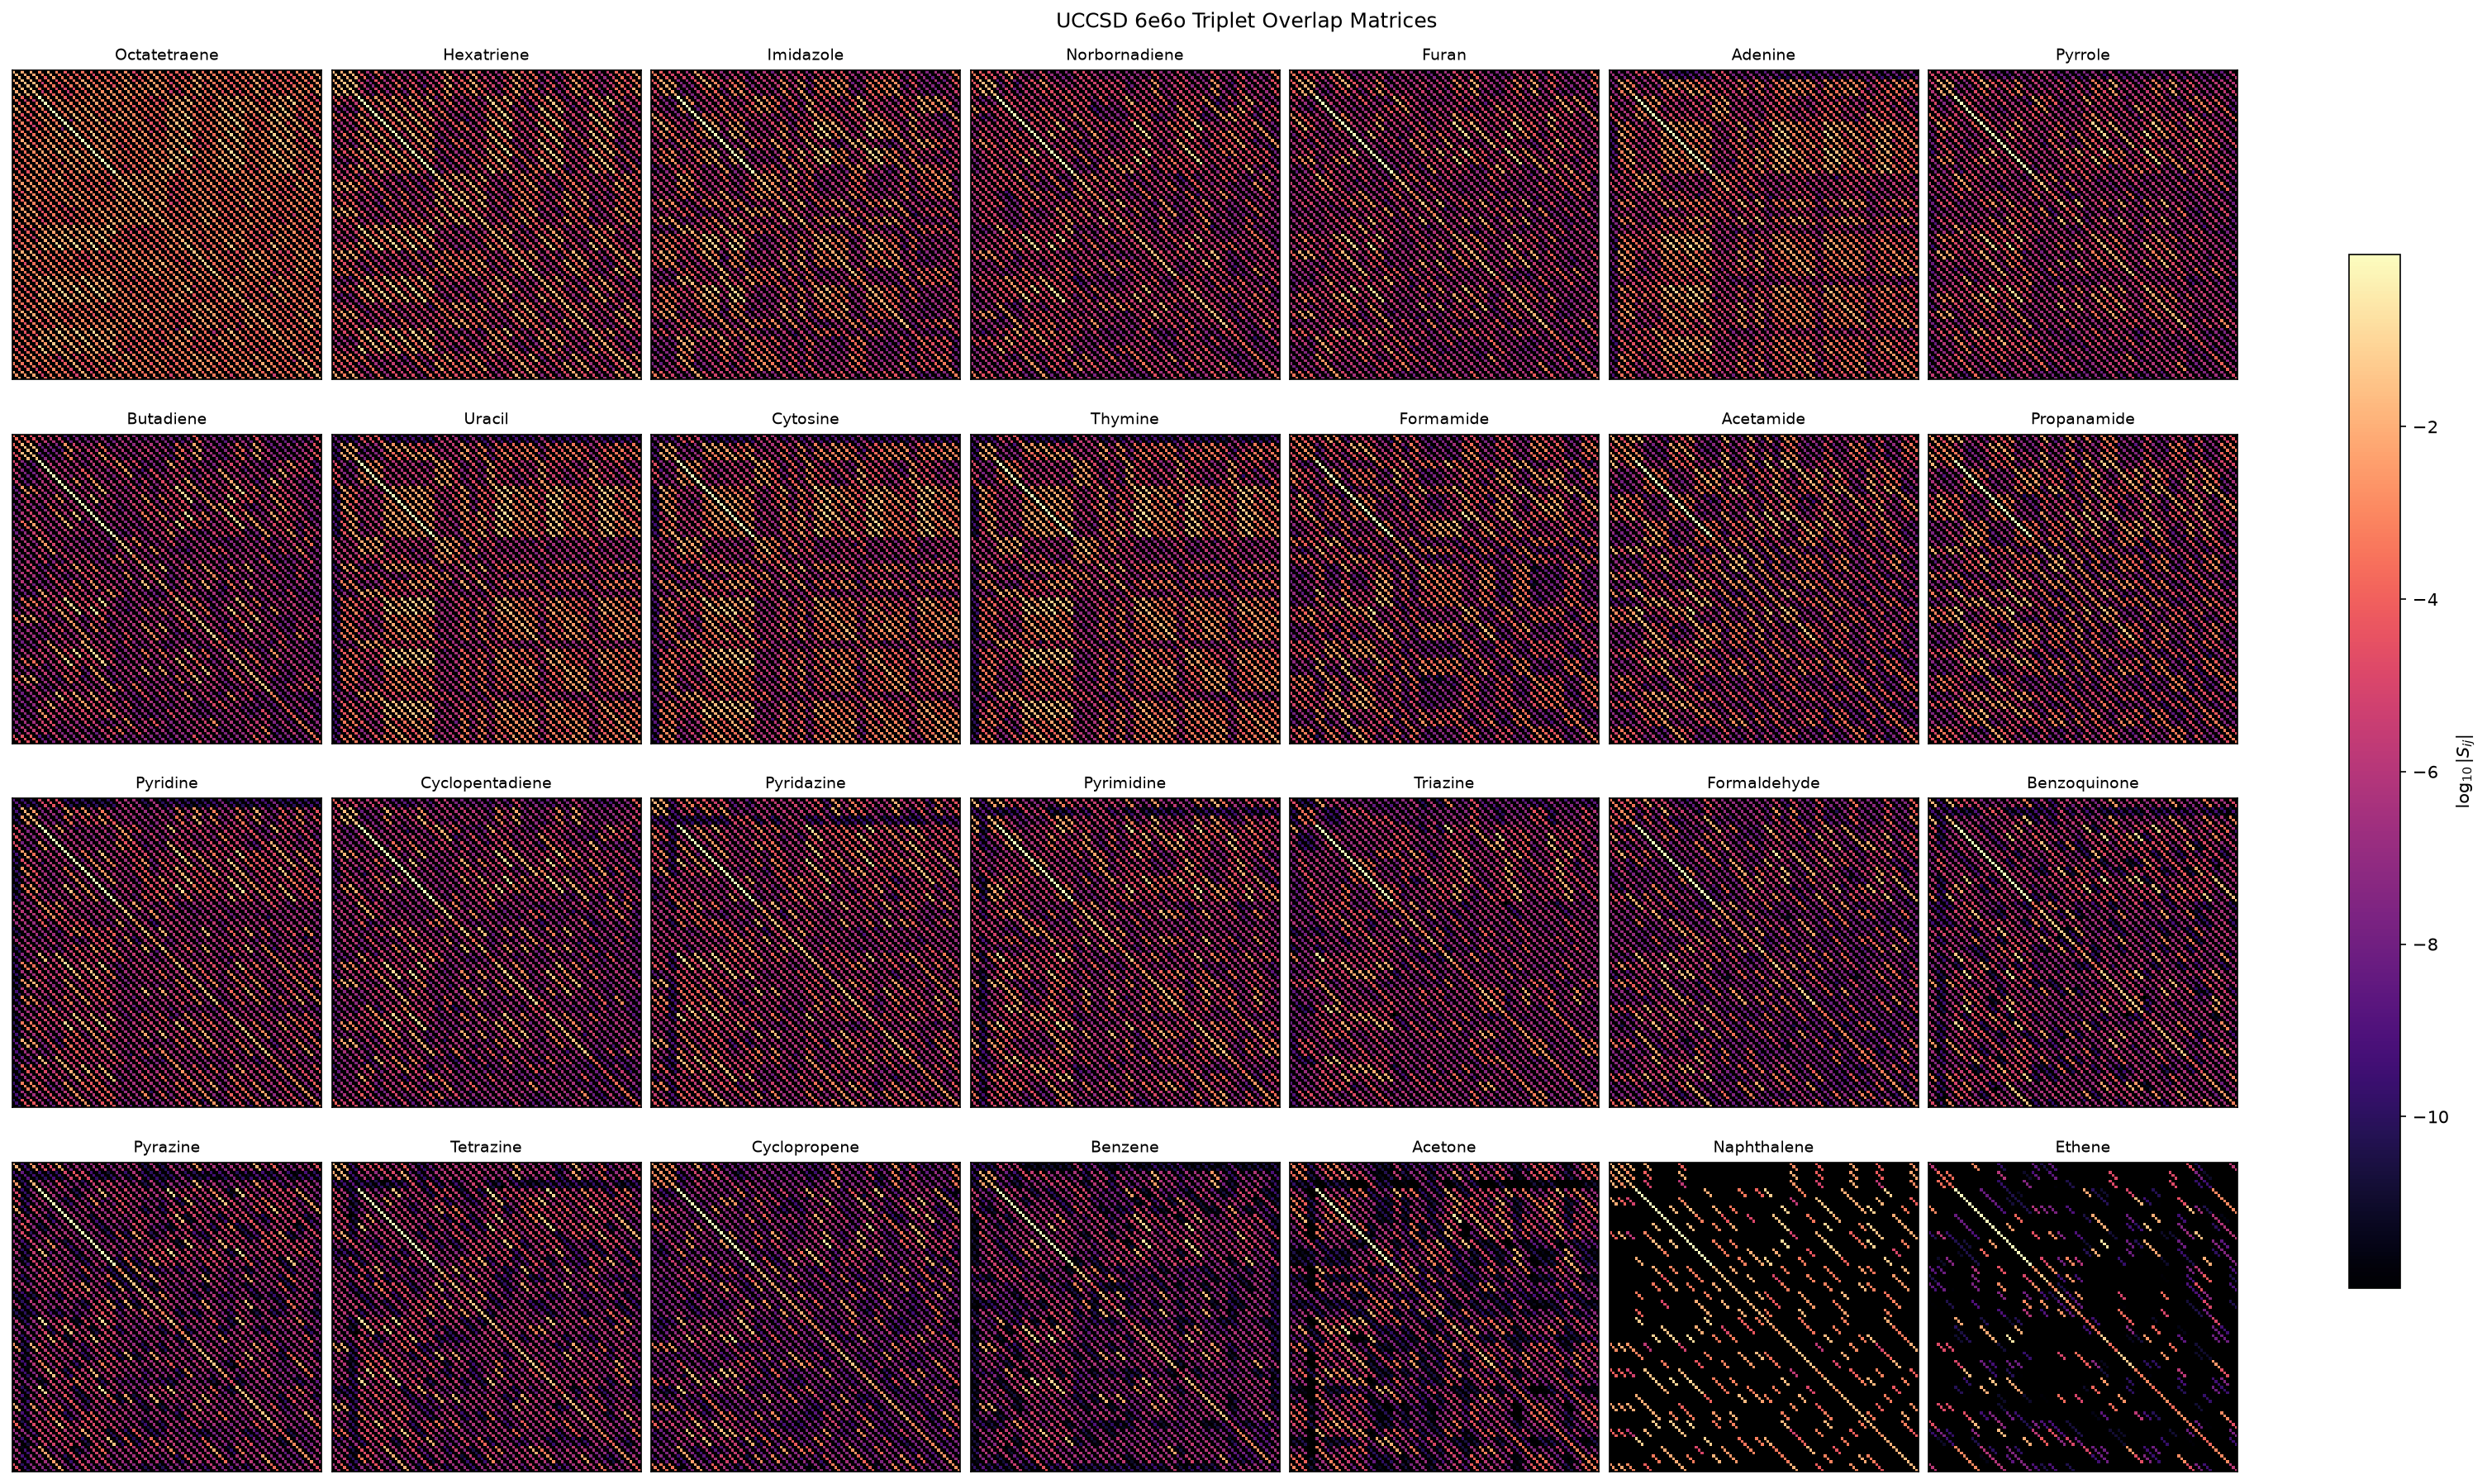

In [7]:
SPARSITY_THRESHOLD = 1e-8
df_uccsd_6e6o = df_uccsd[df_uccsd["active_space"] == "6e6o"]
reordered_overlap_matrices = {}

for expansion in expansions:
    df_expansion = df_uccsd_6e6o[df_uccsd_6e6o["expansion"] == expansion]
    matrix_data = []

    for row in df_expansion.itertuples(index=False):
        nonzero_percent = 100 * np.count_nonzero(np.abs(row.S) >= SPARSITY_THRESHOLD) / row.S.size
        reordered_S = reorder_mat(row.S, "6e6o", expansion)
        matrix_data.append((row.molecule, reordered_S, nonzero_percent))

    reordered_overlap_matrices[expansion] = sorted(
        matrix_data, key=lambda data: data[2], reverse=True
    )

singlet_overlap_figure = plot_reordered_overlap_heatmaps(
    reordered_overlap_matrices["singlet"], "6e6o", "singlet"
)
triplet_overlap_figure = plot_reordered_overlap_heatmaps(
    reordered_overlap_matrices["triplet"], "6e6o", "triplet"
)
save_figure(singlet_overlap_figure, "matrix_heatmaps", "uccsd_6e6o_singlet_overlap")
save_figure(triplet_overlap_figure, "matrix_heatmaps", "uccsd_6e6o_triplet_overlap")
show_scrollable_figs([singlet_overlap_figure, triplet_overlap_figure])

## Shots and heatmaps


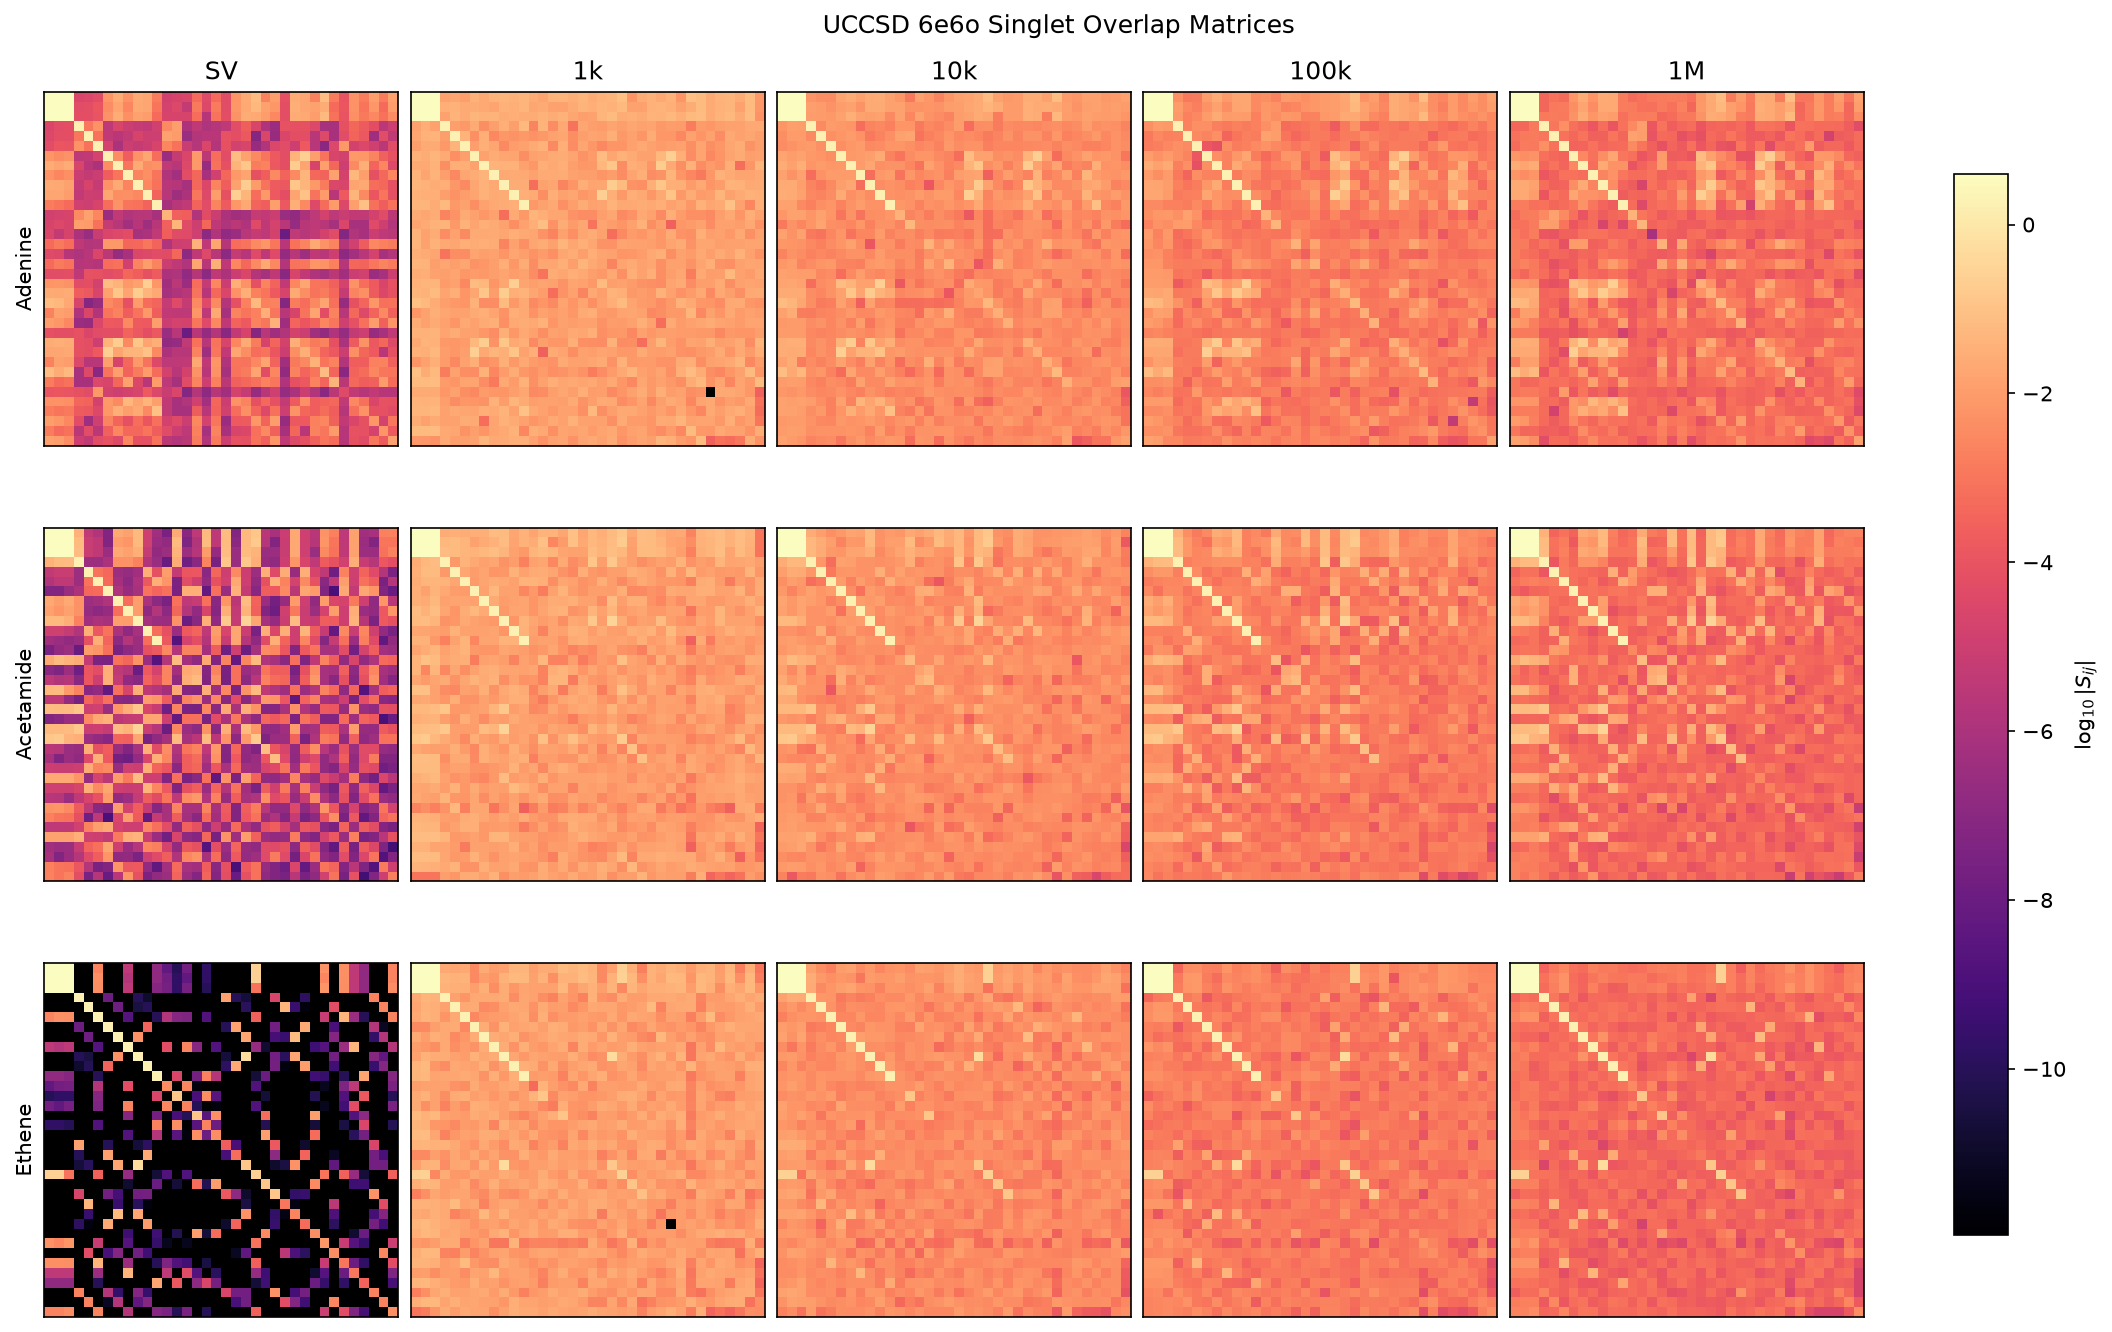

In [8]:
molecules = ("Adenine", "Acetamide", "Ethene")
shot_counts = (1_000, 10_000, 100_000, 1_000_000)
df_shot_heatmaps = df_shots[
    (df_shots["active_space"] == "6e6o")
    & (df_shots["ansatz"] == "UCCSD")
    & (df_shots["expansion"] == "singlet")
    & (df_shots["repeat"] == 0)
    & df_shots["molecule"].isin(molecules)
    & df_shots["n_shots"].isin(shot_counts)
]

shot_overlap_matrices = {}
for molecule in molecules:
    df_molecule = df_shot_heatmaps[df_shot_heatmaps["molecule"] == molecule]
    matrices = {"SV": reorder_mat(df_molecule.iloc[0]["S_sv"], "6e6o", "singlet")}

    for n_shots in shot_counts:
        S_shots = df_molecule[df_molecule["n_shots"] == n_shots].iloc[0]["S_shots"]
        matrices[f"{n_shots // 1000}k" if n_shots < 1_000_000 else "1M"] = (
            reorder_mat(S_shots, "6e6o", "singlet")
        )

    shot_overlap_matrices[molecule] = matrices

shot_overlap_figure = plot_shot_overlap_heatmaps(shot_overlap_matrices, "6e6o")
save_figure(shot_overlap_figure, "matrix_heatmaps", "uccsd_6e6o_shot_overlap")
show_scrollable_figs([shot_overlap_figure])